In [5]:
import os

# Check current working directory
print("Current directory:", os.getcwd())

# Search for the file
for root, dirs, files in os.walk('..'):
    for file in files:
        if 'nike_clean' in file:
            print("Found:", os.path.join(root, file))

Current directory: C:\Users\chitr\BrandLensAI
Found: ..\AppData\Roaming\Microsoft\Office\Recent\nike_clean_final.LNK
Found: ..\AppData\Roaming\Microsoft\Windows\Recent\nike_clean_final.lnk
Found: ..\BrandLensAI\data\processed\nike_clean.csv
Found: ..\BrandLensAI\data\processed\nike_clean_final.csv


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Load clean data
df_clean = pd.read_csv('data/processed/nike_clean_final.csv')
print(f"Loaded {len(df_clean)} clean tweets")
print(df_clean['sentiment'].value_counts())

Loaded 9941 clean tweets
sentiment
negative    4980
positive    4961
Name: count, dtype: int64


In [9]:
analyzer = SentimentIntensityAnalyzer()

def get_vader_scores(text):
    scores = analyzer.polarity_scores(str(text))
    compound = scores['compound']
    if compound >= 0.05:
        label = 'positive'
    elif compound <= -0.05:
        label = 'negative'
    else:
        label = 'neutral'
    return pd.Series([scores['pos'], scores['neg'],
                      scores['neu'], compound, label])

df_clean[['vader_pos', 'vader_neg', 'vader_neu',
          'vader_compound', 'vader_label']] = df_clean['clean_text'].apply(get_vader_scores)

# Results
print("VADER Sentiment Distribution:")
print(df_clean['vader_label'].value_counts())
print(f"\nPercentages:")
print(df_clean['vader_label'].value_counts(normalize=True).mul(100).round(1))
print(f"\nAverage compound score: {df_clean['vader_compound'].mean():.3f}")

VADER Sentiment Distribution:
vader_label
positive    4785
neutral     2759
negative    2397
Name: count, dtype: int64

Percentages:
vader_label
positive    48.1
neutral     27.8
negative    24.1
Name: proportion, dtype: float64

Average compound score: 0.152


In [13]:
print("Average VADER compound score by original label:")
print(df_clean.groupby('sentiment')['vader_compound'].mean().round(3))

print("\nVADER label vs Original label comparison:")
print(pd.crosstab(df_clean['sentiment'], 
                  df_clean['vader_label'], 
                  normalize='index').mul(100).round(1))

Average VADER compound score by original label:
sentiment
negative   -0.010
positive    0.314
Name: vader_compound, dtype: float64

VADER label vs Original label comparison:
vader_label  negative  neutral  positive
sentiment                               
negative         38.2     27.6      34.3
positive         10.0     27.9      62.0


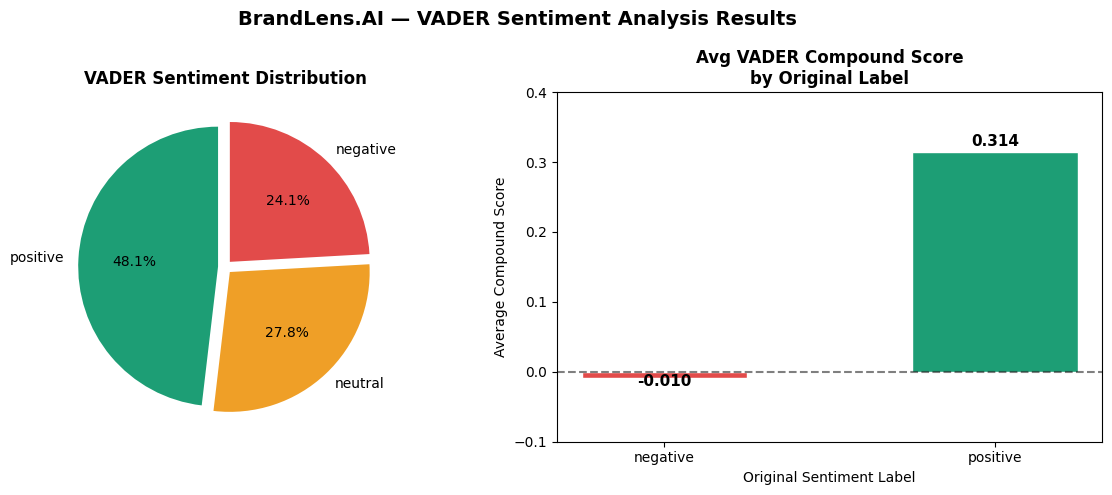

[OK] Chart saved


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('BrandLens.AI — VADER Sentiment Analysis Results', 
             fontsize=14, fontweight='bold')

# Pie chart
colors = ['#1D9E75', '#EF9F27', '#E24B4A']
vader_counts = df_clean['vader_label'].value_counts()
axes[0].pie(vader_counts.values, 
            labels=vader_counts.index,
            autopct='%1.1f%%',
            colors=colors,
            startangle=90,
            explode=(0.05, 0.05, 0.05))
axes[0].set_title('VADER Sentiment Distribution', fontweight='bold')

# Bar chart
compound_means = df_clean.groupby('sentiment')['vader_compound'].mean()
bars = axes[1].bar(compound_means.index, 
                   compound_means.values,
                   color=['#E24B4A', '#1D9E75'],
                   edgecolor='white',
                   width=0.5)

# Add value labels on each bar
for bar, val in zip(bars, compound_means.values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 val + 0.005 if val >= 0 else val - 0.015,
                 f'{val:.3f}',
                 ha='center', va='bottom', 
                 fontsize=11, fontweight='bold')

axes[1].set_title('Avg VADER Compound Score\nby Original Label', 
                   fontweight='bold')
axes[1].set_xlabel('Original Sentiment Label')
axes[1].set_ylabel('Average Compound Score')
axes[1].set_ylim(-0.1, 0.4)
axes[1].axhline(y=0, color='black', linestyle='--', alpha=0.5)
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('outputs/vader_sentiment_results.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("[OK] Chart saved")

In [20]:
df_clean.to_csv('data/processed/nike_vader_scored.csv', index=False)
print("[OK] VADER scored dataset saved to data/processed/nike_vader_scored.csv")
print(f"\nDataset shape: {df_clean.shape}")
print(f"\nColumns: {list(df_clean.columns)}")

[OK] VADER scored dataset saved to data/processed/nike_vader_scored.csv

Dataset shape: (9941, 15)

Columns: ['sentiment', 'id', 'date', 'query', 'user', 'text', 'text_length', 'word_count', 'clean_text', 'clean_word_count', 'vader_pos', 'vader_neg', 'vader_neu', 'vader_compound', 'vader_label']


In [16]:
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

df_clean = pd.read_csv('data/processed/nike_vader_scored.csv')
print(f"Loaded {len(df_clean)} tweets")
print(df_clean['vader_label'].value_counts())

Task was destroyed but it is pending!
task: <Task pending name='Task-215' coro=<_async_in_context.<locals>.run_in_context() done, defined at C:\Users\chitr\BrandLensAI\venv\Lib\site-packages\ipykernel\utils.py:57> wait_for=<Task pending name='Task-216' coro=<Kernel.shell_main() running at C:\Users\chitr\BrandLensAI\venv\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at C:\Users\chitr\BrandLensAI\venv\Lib\site-packages\zmq\eventloop\zmqstream.py:563]>
C:\Users\chitr\BrandLensAI\venv\Lib\site-packages\sklearn\utils\_metadata_requests.py:109: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  from sklearn.utils._bunch import Bunch
Task was destroyed but it is pending!
task: <Task pending name='Task-216' coro=<Kernel.shell_main() running at C:\Users\chitr\BrandLensAI\venv\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]>


Loaded 9941 tweets
vader_label
positive    4785
neutral     2759
negative    2397
Name: count, dtype: int64


In [17]:
# Compare VADER labels against original labels
# Filter out neutral since original dataset has no neutral class
df_eval = df_clean[df_clean['vader_label'] != 'neutral'].copy()

print(f"Tweets used for evaluation (excluding neutral): {len(df_eval)}")
print(f"\nClassification Report:")
print(classification_report(df_eval['sentiment'], 
                            df_eval['vader_label'],
                            target_names=['negative', 'positive']))

Tweets used for evaluation (excluding neutral): 7182

Classification Report:
              precision    recall  f1-score   support

    negative       0.79      0.53      0.63      3607
    positive       0.64      0.86      0.74      3575

    accuracy                           0.69      7182
   macro avg       0.72      0.69      0.68      7182
weighted avg       0.72      0.69      0.68      7182



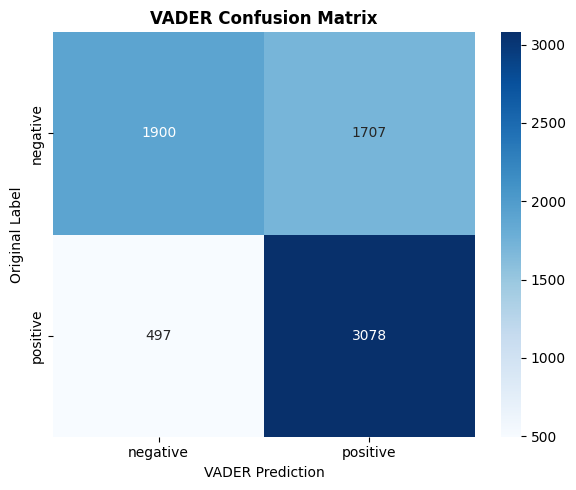

[OK] Confusion matrix saved


In [18]:
cm = confusion_matrix(df_eval['sentiment'], 
                      df_eval['vader_label'],
                      labels=['negative', 'positive'])

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['negative', 'positive'],
            yticklabels=['negative', 'positive'])
plt.title('VADER Confusion Matrix', fontweight='bold')
plt.ylabel('Original Label')
plt.xlabel('VADER Prediction')
plt.tight_layout()
plt.savefig('outputs/vader_confusion_matrix.png', dpi=150)
plt.show()
print("[OK] Confusion matrix saved")

In [19]:
# Save evaluation summary
eval_summary = {
    'Model': 'VADER',
    'Accuracy': 0.69,
    'Negative Precision': 0.79,
    'Negative Recall': 0.53,
    'Negative F1': 0.63,
    'Positive Precision': 0.64,
    'Positive Recall': 0.86,
    'Positive F1': 0.74,
    'Macro F1': 0.68
}

eval_df = pd.DataFrame([eval_summary])
eval_df.to_csv('data/processed/vader_evaluation.csv', index=False)
print("[OK] Evaluation saved")
print(eval_df.to_string(index=False))

[OK] Evaluation saved
Model  Accuracy  Negative Precision  Negative Recall  Negative F1  Positive Precision  Positive Recall  Positive F1  Macro F1
VADER      0.69                0.79             0.53         0.63                0.64             0.86         0.74      0.68
